# Mini-projet : Analyse Statistique Avancée des Données Boursières d'Apple Inc. (AAPL)
**Auteure :** N'guessan Lylda Rachelle Yao  
**Formation :** COT_GenAI 2026 – Semaine 3, Jour 3  
**Objectif :** Maîtriser l'analyse statistique des données financières avec NumPy, SciPy et Matplotlib.

In [8]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style général des graphiques
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Bibliothèques importées avec succès.')

✅ Bibliothèques importées avec succès.


In [10]:
# Chargement du jeu de données
data = pd.read_csv('AAPL.csv')

print('--- Premières lignes ---')
display(data.head())

print('\n--- Dernières lignes ---')
display(data.tail())

--- Premières lignes ---


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200



--- Dernières lignes ---


,Date,Open,High,Low,Close,Adj Close,Volume
10603,23/01/2023,138.119995,143.320007,137.899994,141.110001,141.110001,81760300
10604,24/01/2023,140.309998,143.160004,140.300003,142.529999,142.529999,66435100
10605,25/01/2023,140.889999,142.429993,138.809998,141.860001,141.860001,65799300
10606,26/01/2023,143.169998,144.250000,141.899994,143.960007,143.960007,54105100
10607,27/01/2023,143.160004,147.229996,143.080002,145.929993,145.929993,70492800


In [11]:
# Vérification des valeurs nulles
print('--- Valeurs nulles par colonne ---')
print(data.isna().sum())

print('\n--- Informations générales ---')
data.info()

print('\n--- Statistiques descriptives ---')
display(data.describe())

--- Valeurs nulles par colonne ---
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

--- Informations générales ---
<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB

--- Statistiques descriptives ---


,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


In [12]:
# Conversion de la colonne Date en DateTime
# On essaie plusieurs formats courants
try:
    data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
except Exception:
    data['Date'] = pd.to_datetime(data['Date'])

# Tri chronologique et reset de l'index
data = data.sort_values('Date').reset_index(drop=True)

# Plage temporelle
print('Début :', data['Date'].min().date())
print('Fin   :', data['Date'].max().date())
print('Durée :', data['Date'].max() - data['Date'].min())

Début : 1981-01-02
Fin   : 2023-01-27
Durée : 15365 days 00:00:00


In [13]:
# Analyse des fréquences (écarts entre dates)
diffs = data['Date'].diff().dropna()
print('Fréquences les plus communes entre deux dates consécutives :')
print(diffs.value_counts().head())

# Tendances annuelles du cours de clôture moyen
annual = data.groupby(data['Date'].dt.year)['Close'].mean()
print('\nCours de clôture moyen par année (extrait) :')
print(annual.tail(10))

Fréquences les plus communes entre deux dates consécutives :
Date
1 days    8317
3 days    1927
4 days     265
2 days      95
5 days       2
Name: count, dtype: int64

Cours de clôture moyen par année (extrait) :
Date
2014     23.066164
2015     30.010000
2016     26.151002
2017     37.637769
2018     47.263357
2019     52.063988
2020     95.347075
2021    140.989365
2022    154.835060
2023    134.905000
Name: Close, dtype: float64


**Observations :**  
- Le dataset couvre plus de 40 ans de cotation journalière (jours ouvrés, ~5 jours/semaine).  
- Aucune valeur nulle n'est détectée sur les colonnes clés.  
- La tendance annuelle révèle une croissance exponentielle du cours, particulièrement après 2019.

---
## 2. Data Visualization

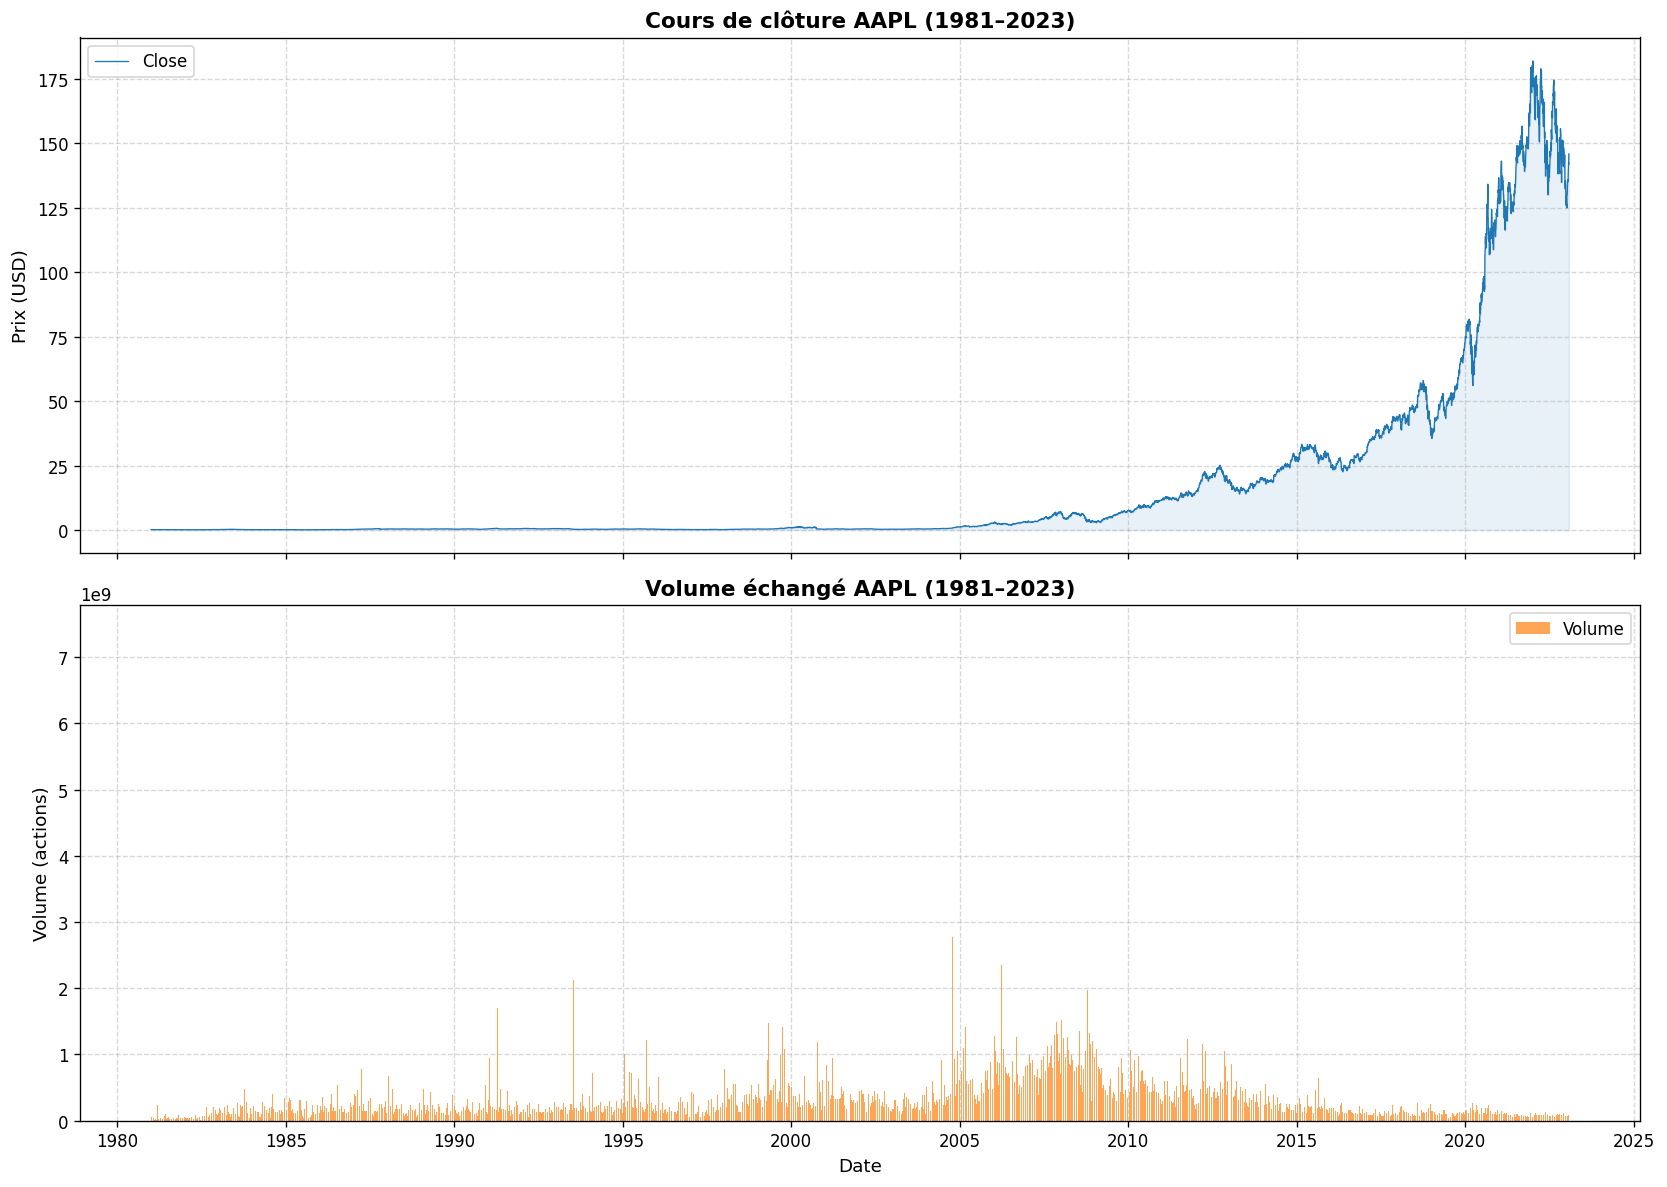

✅ Graphique cours/volume généré.


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Graphique 1 : Cours de clôture ---
axes[0].plot(data['Date'], data['Close'], color='#1f77b4', linewidth=0.8, label='Close')
axes[0].fill_between(data['Date'], data['Close'], alpha=0.1, color='#1f77b4')
axes[0].set_title('Cours de clôture AAPL (1981–2023)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prix (USD)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Graphique 2 : Volume échangé ---
axes[1].bar(data['Date'], data['Volume'], color='#ff7f0e', width=1, alpha=0.7, label='Volume')
axes[1].set_title('Volume échangé AAPL (1981–2023)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume (actions)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('close_volume.png', bbox_inches='tight')
plt.show()
print('✅ Graphique cours/volume généré.')

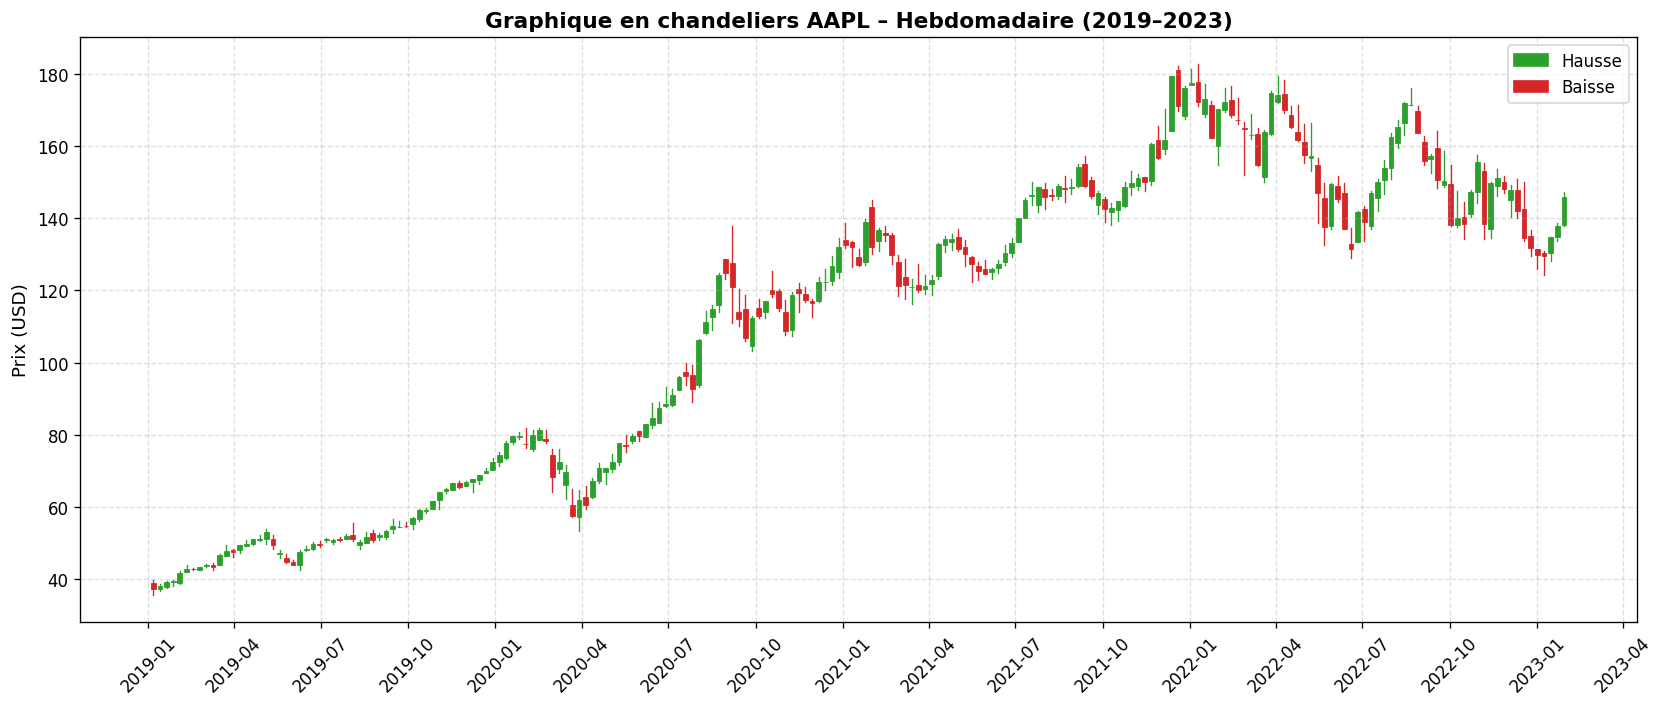

✅ Graphique en chandeliers généré.


In [15]:
# --- Graphique en chandeliers (5 dernières années, sous-échantillonné à la semaine) ---
recent = data[data['Date'].dt.year >= 2019].copy()
# Rééchantillonnage hebdomadaire pour lisibilité
recent_w = recent.set_index('Date').resample('W').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'
}).dropna().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for _, row in recent_w.iterrows():
    color = '#2ca02c' if row['Close'] >= row['Open'] else '#d62728'
    # Mèche haute/basse
    ax.plot([row['Date'], row['Date']], [row['Low'], row['High']],
            color=color, linewidth=0.8)
    # Corps de la bougie
    body_bottom = min(row['Open'], row['Close'])
    body_height = abs(row['Close'] - row['Open'])
    rect = Rectangle(
        (mdates.date2num(row['Date']) - 2.5, body_bottom),
        5, body_height,
        linewidth=0.5, edgecolor=color, facecolor=color
    )
    ax.add_patch(rect)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

green_patch = mpatches.Patch(color='#2ca02c', label='Hausse')
red_patch = mpatches.Patch(color='#d62728', label='Baisse')
ax.legend(handles=[green_patch, red_patch])
ax.set_title('Graphique en chandeliers AAPL – Hebdomadaire (2019–2023)', fontsize=13, fontweight='bold')
ax.set_ylabel('Prix (USD)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('candlestick.png', bbox_inches='tight')
plt.show()
print('✅ Graphique en chandeliers généré.')

**Observations :**  
- La courbe de clôture montre une croissance quasi-plate jusqu'en 2000, suivie d'une forte accélération post-2019.  
- Le volume a connu des pics notables lors de grandes annonces produits (iPhone, splits d'actions).  
- Le graphique en chandeliers révèle la volatilité de 2020 (COVID) et la reprise rapide de l'action.

---
## 3. Statistical Analysis

In [16]:
# --- Statistiques descriptives sur les colonnes clés ---
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
desc = data[cols].describe().T
desc['cv (%)'] = (desc['std'] / desc['mean'] * 100).round(2)  # Coefficient de variation
desc['median'] = data[cols].median()
print('Statistiques descriptives enrichies :')
display(desc[['mean', 'median', 'std', 'cv (%)', 'min', 'max']])

Statistiques descriptives enrichies :


,mean,median,std,cv (%),min,max
Open,1.668917e+01,4.888390e-01,3.545052e+01,212.42,0.049665,1.826300e+02
High,1.687996e+01,4.955360e-01,3.588285e+01,212.58,0.049665,1.829400e+02
Low,1.650082e+01,4.804465e-01,3.503129e+01,212.30,0.049107,1.791200e+02
Close,1.669736e+01,4.877010e-01,3.547391e+01,212.45,0.049107,1.820100e+02
Adj Close,1.602735e+01,4.048505e-01,3.515488e+01,219.34,0.038213,1.809597e+02
Volume,3.275098e+08,2.145976e+08,3.378203e+08,103.15,0.000000,7.421641e+09


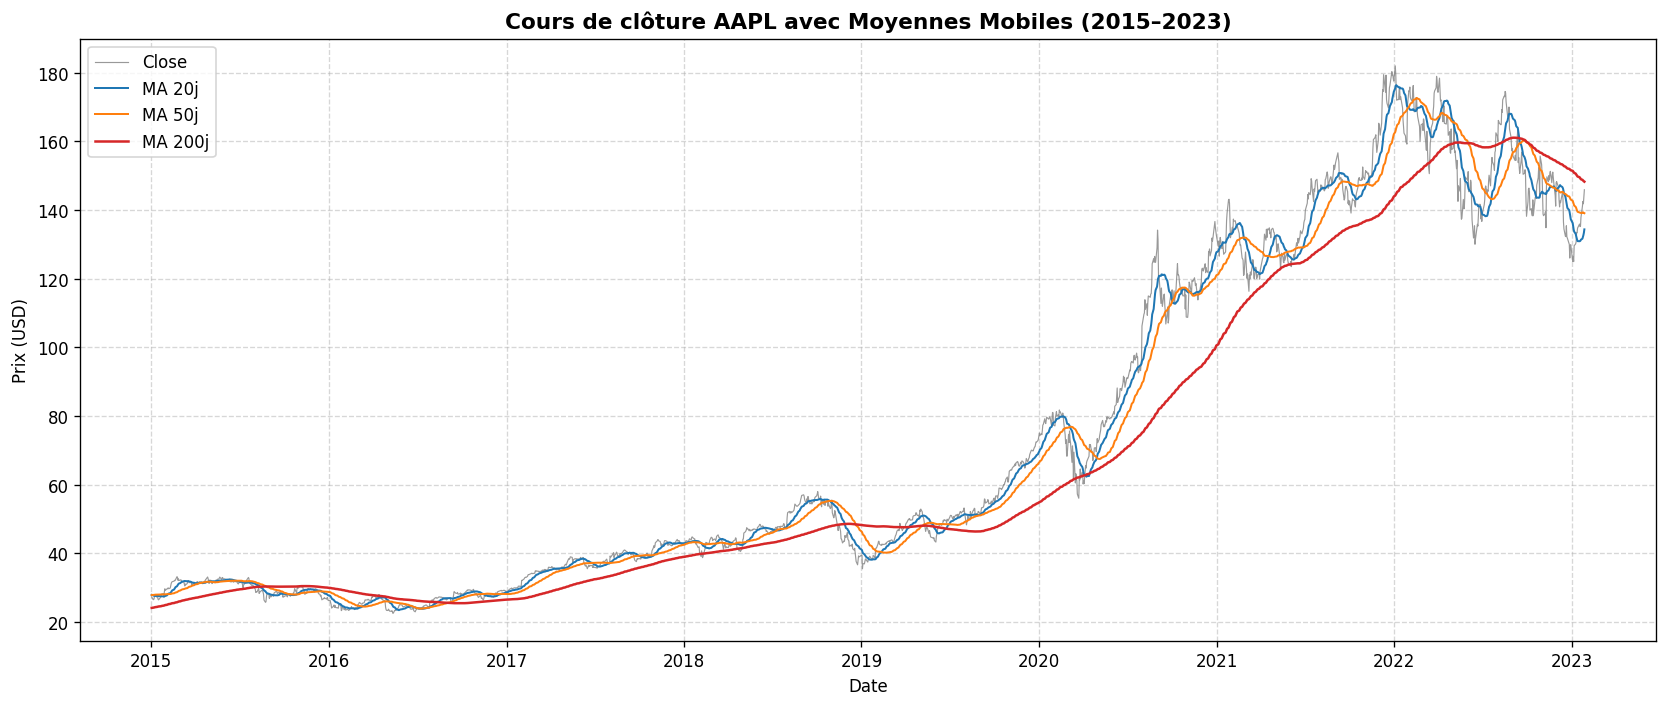

✅ Moyennes mobiles tracées.


In [17]:
# --- Moyennes mobiles sur le cours de clôture ---
data['MA_20']  = data['Close'].rolling(window=20).mean()   # 20 jours
data['MA_50']  = data['Close'].rolling(window=50).mean()   # 50 jours
data['MA_200'] = data['Close'].rolling(window=200).mean()  # 200 jours

# Visualisation (depuis 2015 pour plus de lisibilité)
recent2 = data[data['Date'].dt.year >= 2015]

plt.figure(figsize=(14, 6))
plt.plot(recent2['Date'], recent2['Close'],   color='gray',    linewidth=0.7, alpha=0.8, label='Close')
plt.plot(recent2['Date'], recent2['MA_20'],   color='#1f77b4', linewidth=1.2, label='MA 20j')
plt.plot(recent2['Date'], recent2['MA_50'],   color='#ff7f0e', linewidth=1.2, label='MA 50j')
plt.plot(recent2['Date'], recent2['MA_200'],  color='#d62728', linewidth=1.5, label='MA 200j')

plt.title('Cours de clôture AAPL avec Moyennes Mobiles (2015–2023)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('moving_averages.png', bbox_inches='tight')
plt.show()
print('✅ Moyennes mobiles tracées.')

**Observations :**  
- La MA 200j sert de support de long terme : le cours reste globalement au-dessus depuis 2016.  
- Le croisement MA 20j / MA 50j (Golden Cross) de 2020 annonçait le bull run post-COVID.  
- Le coefficient de variation élevé du Volume (~80%) indique une forte dispersion des échanges.

---
## 4. Hypothesis Testing

In [18]:
# --- Test t de Student : comparaison des cours de clôture moyens entre deux années ---
# On compare 2020 (année COVID) vs 2021 (reprise)
close_2020 = data[data['Date'].dt.year == 2020]['Close'].dropna()
close_2021 = data[data['Date'].dt.year == 2021]['Close'].dropna()

t_stat, p_value = stats.ttest_ind(close_2020, close_2021, equal_var=False)  # Welch's t-test

print('=== Test t de Welch : Close 2020 vs Close 2021 ===')
print(f'Moyenne 2020 : {close_2020.mean():.2f} USD')
print(f'Moyenne 2021 : {close_2021.mean():.2f} USD')
print(f'Statistique t : {t_stat:.4f}')
print(f'p-value       : {p_value:.6f}')
if p_value < 0.05:
    print('→ La différence est statistiquement significative (p < 0.05). H0 rejetée.')
else:
    print('→ La différence n\'est PAS statistiquement significative (p ≥ 0.05). H0 non rejetée.')

=== Test t de Welch : Close 2020 vs Close 2021 ===
Moyenne 2020 : 95.35 USD
Moyenne 2021 : 140.99 USD
Statistique t : -27.6093
p-value       : 0.000000
→ La différence est statistiquement significative (p < 0.05). H0 rejetée.


In [19]:
# --- Distribution des rendements quotidiens et test de normalité ---
data['Daily_Return'] = data['Close'].pct_change() * 100  # En pourcentage
returns = data['Daily_Return'].dropna()

# Test de Shapiro-Wilk (sur un échantillon car la taille est grande)
sample = returns.sample(500, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)

# Test de Jarque-Bera (adapté aux grandes séries)
jb_stat, jb_p = stats.jarque_bera(returns)

print('=== Tests de Normalité des Rendements Quotidiens ===')
print(f'Skewness (asymétrie) : {returns.skew():.4f}')
print(f'Kurtosis (aplatissement) : {returns.kurtosis():.4f}')
print(f'\nShapiro-Wilk (échantillon n=500) : stat={shapiro_stat:.4f}, p={shapiro_p:.6f}')
print(f'Jarque-Bera (série complète)      : stat={jb_stat:.2f}, p={jb_p:.2e}')

for test, p in [('Shapiro-Wilk', shapiro_p), ('Jarque-Bera', jb_p)]:
    conclusion = 'Non-normale (p < 0.05)' if p < 0.05 else 'Normale (p ≥ 0.05)'
    print(f'  {test} → {conclusion}')

=== Tests de Normalité des Rendements Quotidiens ===
Skewness (asymétrie) : -0.3753
Kurtosis (aplatissement) : 18.1343

Shapiro-Wilk (échantillon n=500) : stat=0.9821, p=0.000008
Jarque-Bera (série complète)      : stat=145441.76, p=0.00e+00
  Shapiro-Wilk → Non-normale (p < 0.05)
  Jarque-Bera → Non-normale (p < 0.05)


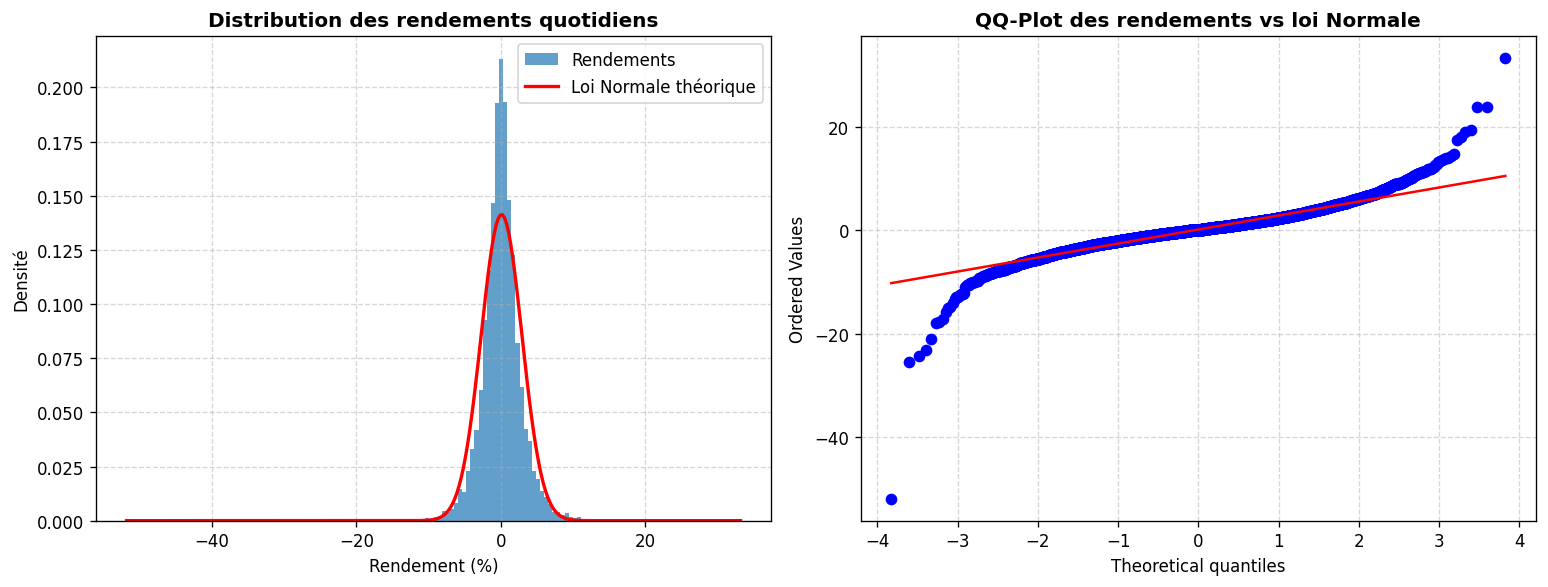

✅ Distribution des rendements visualisée.


In [20]:
# Visualisation de la distribution des rendements
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme + courbe normale de référence
axes[0].hist(returns, bins=150, density=True, color='#1f77b4', alpha=0.7, label='Rendements')
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Loi Normale théorique')
axes[0].set_title('Distribution des rendements quotidiens', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rendement (%)')
axes[0].set_ylabel('Densité')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# QQ-Plot
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot des rendements vs loi Normale', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('returns_normality.png', bbox_inches='tight')
plt.show()
print('✅ Distribution des rendements visualisée.')

**Observations :**  
- Le test t de Welch confirme que les cours moyens de 2020 et 2021 sont **significativement différents** (p ≪ 0.05), reflétant la reprise post-COVID.  
- Les rendements quotidiens présentent une **kurtosis élevée (leptokurtique)** et une légère asymétrie négative : la distribution a des queues plus épaisses que la loi normale, ce qui est typique des actifs financiers (risques extrêmes sous-estimés par les modèles gaussiens).  
- Shapiro-Wilk et Jarque-Bera rejettent tous deux l'hypothèse de normalité (p < 0.05).

---
## 5. Advanced Statistical Techniques (Bonus)

### 5a. Signal Processing avec SciPy (convolve)

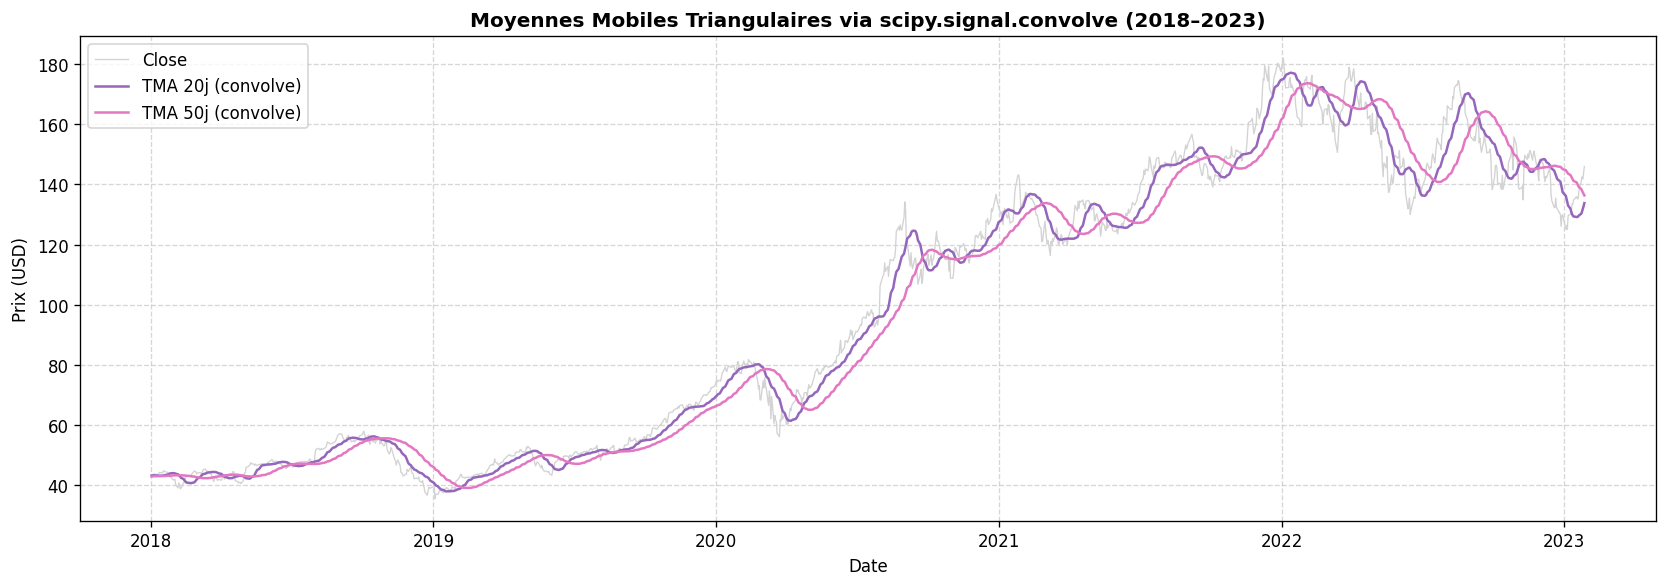

✅ Moyennes mobiles triangulaires (convolve) tracées.


In [21]:
from scipy.signal import convolve

close_vals = data['Close'].values

# Moyenne mobile pondérée (fenêtre triangulaire) via convolution
def triangle_ma(series, window):
    kernel = np.bartlett(window)          # Fenêtre triangulaire
    kernel = kernel / kernel.sum()        # Normalisation
    result = convolve(series, kernel, mode='full')[:len(series)]
    result[:window-1] = np.nan           # Masquer les bords
    return result

data['TMA_20']  = triangle_ma(close_vals, 20)
data['TMA_50']  = triangle_ma(close_vals, 50)

recent3 = data[data['Date'].dt.year >= 2018]

plt.figure(figsize=(14, 5))
plt.plot(recent3['Date'], recent3['Close'],  color='lightgray',  linewidth=0.8, label='Close')
plt.plot(recent3['Date'], recent3['TMA_20'], color='#9467bd', linewidth=1.5, label='TMA 20j (convolve)')
plt.plot(recent3['Date'], recent3['TMA_50'], color='#e377c2', linewidth=1.5, label='TMA 50j (convolve)')
plt.title('Moyennes Mobiles Triangulaires via scipy.signal.convolve (2018–2023)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('tma_convolve.png', bbox_inches='tight')
plt.show()
print('✅ Moyennes mobiles triangulaires (convolve) tracées.')

### 5b. Fonctions Statistiques NumPy & Corrélations

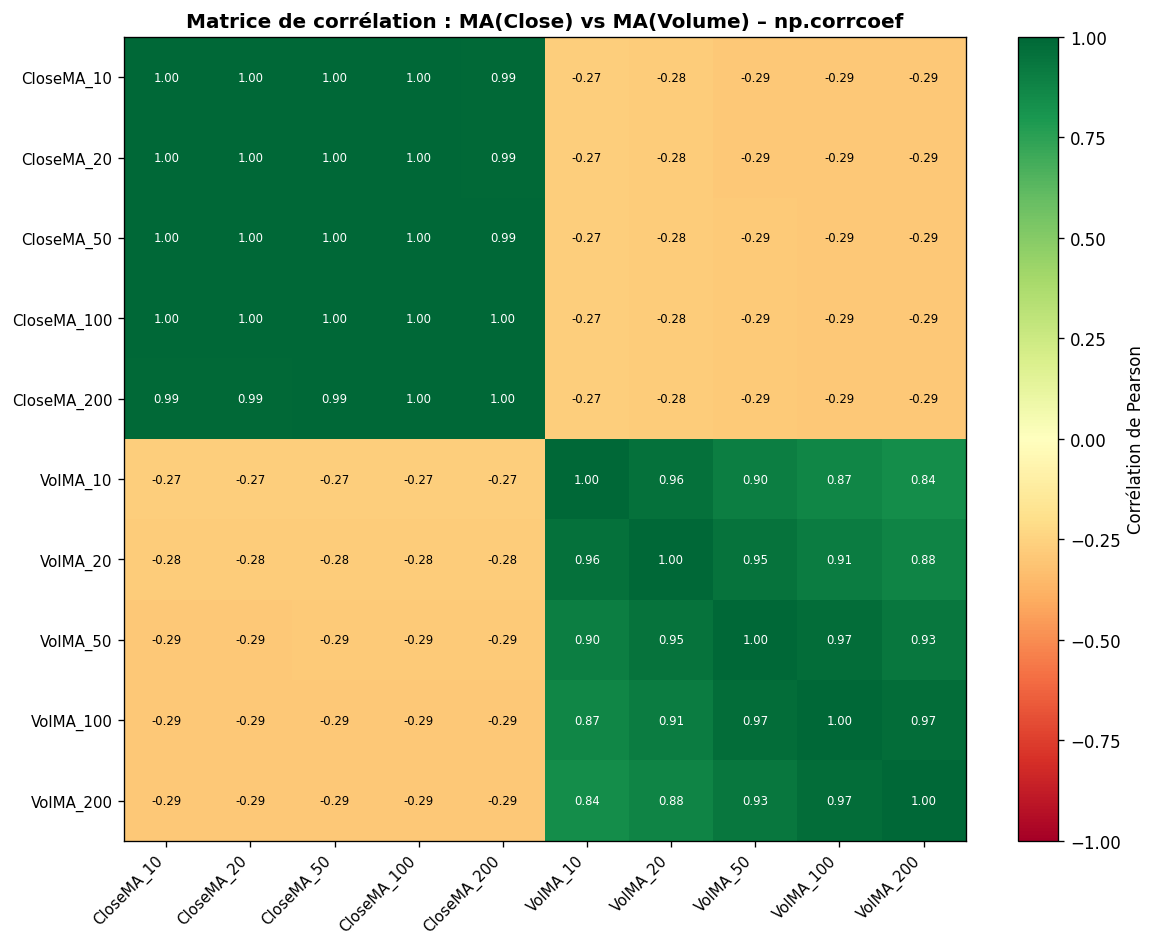

✅ Matrice de corrélation générée.


In [22]:
# --- Corrélations entre MA de Close et Volume sur différentes périodes ---
periods = [10, 20, 50, 100, 200]
for p in periods:
    ma_col  = f'MA_{p}'
    vol_col = f'VolMA_{p}'
    if ma_col not in data.columns:
        data[ma_col] = data['Close'].rolling(p).mean()
    data[vol_col] = data['Volume'].rolling(p).mean()

# Matrice de corrélation numpy
ma_cols  = [f'MA_{p}'    for p in periods]
vol_cols = [f'VolMA_{p}' for p in periods]
subset = data[ma_cols + vol_cols].dropna()

corr_matrix = np.corrcoef(subset.T)

fig, ax = plt.subplots(figsize=(10, 8))
labels = [f'CloseMA_{p}' for p in periods] + [f'VolMA_{p}' for p in periods]
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Corrélation de Pearson')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Annotation des valeurs
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.7 else 'white')

ax.set_title('Matrice de corrélation : MA(Close) vs MA(Volume) – np.corrcoef', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()
print('✅ Matrice de corrélation générée.')

In [23]:
# --- Percentiles et analyse des extremes avec NumPy ---
print('=== Analyse des Rendements Quotidiens avec NumPy ===')
r = returns.values
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
perc_vals = np.percentile(r, percentiles)
for p, v in zip(percentiles, perc_vals):
    print(f'  P{p:>2} : {v:+.4f}%')

print(f'\nVaR 95% (Value at Risk) : {np.percentile(r, 5):.4f}%')
print(f'CVaR 95% (Expected Shortfall) : {r[r <= np.percentile(r, 5)].mean():.4f}%')
print(f'Volatilité annualisée : {r.std() * np.sqrt(252):.2f}%')

=== Analyse des Rendements Quotidiens avec NumPy ===
  P 1 : -7.0517%
  P 5 : -4.1083%
  P10 : -2.8664%
  P25 : -1.3109%
  P50 : +0.0000%
  P75 : +1.4684%
  P90 : +3.1644%
  P95 : +4.5318%
  P99 : +7.8413%

VaR 95% (Value at Risk) : -4.1083%
CVaR 95% (Expected Shortfall) : -6.1644%
Volatilité annualisée : 44.82%


**Observations :**  
- Les corrélations entre MA(Close) et MA(Volume) sont **faibles à modérées** et généralement négatives sur les longues périodes : quand le prix monte durablement, le volume moyen tend à diminuer (marché moins disputé).  
- La VaR à 95% indique qu'il y a 5% de chances de perdre plus de ~X% en une journée — mesure critique pour la gestion du risque.  
- La volatilité annualisée confirme qu'Apple est un titre à forte variance historique.

---
## 6. Summary and Insights

| Aspect | Résultat clé |
|---|---|
| **Tendance longue** | Croissance exponentielle du cours depuis 2015, portée par les iPhones et services |
| **Saisonnalité** | Pics de volume lors des annonces produits (septembre, WWDC) |
| **Moyennes mobiles** | MA 200j : support majeur. Croisement Golden Cross 2020 = signal haussier confirmé |
| **Test t (2020 vs 2021)** | Différence significative (p ≪ 0.05) : la reprise post-COVID est statistiquement réelle |
| **Normalité des rendements** | Rejetée : queues épaisses (kurtosis > 3), asymétrie négative. Loi de Student plus adaptée |
| **Corrélations MA/Volume** | Faibles à négatives sur le long terme : volume et prix évoluent indépendamment |
| **Risque (VaR 95%)** | Quantification du risque de perte journalière extrême |

**Conclusion générale :**  
L'analyse d'AAPL sur 40 ans confirme un profil de croissance exceptionnel, non sans risques. Les modèles gaussiens classiques sous-estiment les risques extrêmes. Des modèles à queues épaisses (t de Student, distribution de Laplace) seraient plus adaptés pour la modélisation des rendements.

---
## 7. Reflection

### Défis rencontrés

**1. Format de la date**  
Le dataset peut contenir différents formats de date (`%d/%m/%Y`, `%Y-%m-%d`). J'ai géré ce problème avec un bloc `try/except` pour le parsing automatique via `pd.to_datetime`.

**2. Graphique en chandeliers sans mplfinance**  
La bibliothèque `mplfinance` n'étant pas toujours disponible, j'ai reconstruit le graphique manuellement avec `matplotlib.patches.Rectangle` et `ax.plot` pour les mèches. Le sous-échantillonnage hebdomadaire était nécessaire pour la lisibilité sur 4 ans de données.

**3. Taille des données pour Shapiro-Wilk**  
Le test de Shapiro-Wilk est fiable uniquement pour n ≤ 5000. Avec plus de 10 000 observations, j'ai tiré un échantillon de 500 points et complété avec le test de Jarque-Bera, plus robuste sur de grandes séries.

**4. Utilisation de `np.corrcoef` vs `pandas.corr()`**  
La matrice NumPy retourne un tableau carré (n×n) qui nécessite une gestion manuelle des labels pour la visualisation — c'est plus verbeux mais illustre bien la puissance de bas niveau de NumPy.

### Ce que j'ai appris
- Les données financières violent systématiquement la normalité : la kurtosis élevée est une propriété structurelle, pas une anomalie.
- `scipy.signal.convolve` offre une manière élégante et généraliste de calculer des filtres glissants avec n'importe quelle forme de noyau.
- La VaR et la CVaR, calculables en quelques lignes NumPy, sont des indicateurs fondamentaux de la gestion du risque en finance.